# Leonard Jones System

## Generating Random Particle Configurations with PBC

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
L = 19
N = 108

gen_particles=[]
while(len(gen_particles)<N):
    flag=0
    x=random.uniform(0, L)
    y=random.uniform(0, L)
    z=random.uniform(0, L)
    for p in gen_particles:
        dx=abs(x-p[0])
        dy=abs(y-p[1])
        dz=abs(z-p[2])
        if dx>L/2:
            dx=L-dx
        if dy>L/2:
            dy=L-dy
        if dz>L/2:
            dz=L-dz
        if np.sqrt(dx**2 + dy**2 + dz**2) < 3:
            flag=1
            break
    if flag==0:
        gen_particles.append((x,y,z))

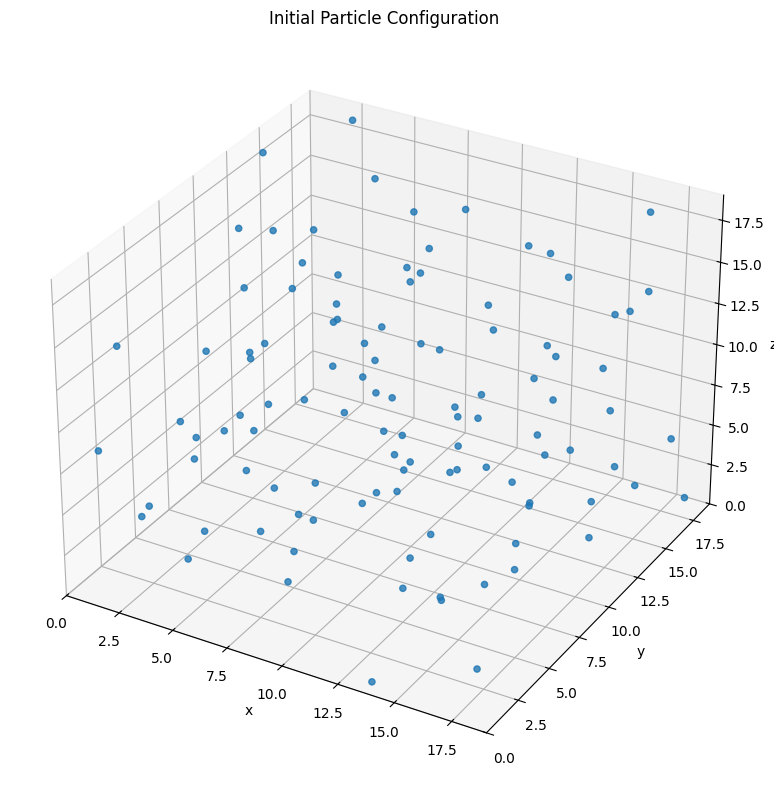

In [23]:
particles = np.array(gen_particles)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(particles[:, 0], particles[:, 1], particles[:, 2], s=20, alpha=0.8)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Initial Particle Configuration")
plt.tight_layout()
plt.show()

### Result: Initial 3D particle configuration
The particles are spread throughout the simulation box while respecting periodic boundaries and a minimum separation. This gives a physically reasonable starting configuration without strong overlaps.

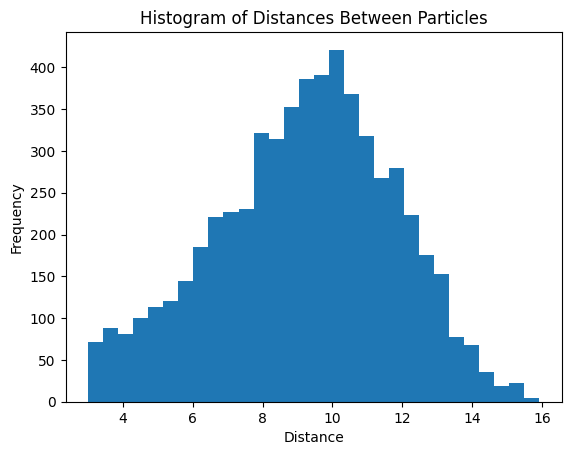

In [3]:
dist=[]
for p in range(len(gen_particles)):
    for q in range(p+1,len(gen_particles)):
        dx=abs(gen_particles[p][0]-gen_particles[q][0])
        dy=abs(gen_particles[p][1]-gen_particles[q][1])
        dz=abs(gen_particles[p][2]-gen_particles[q][2])
        if dx>L/2:
            dx=L-dx
        if dy>L/2:
            dy=L-dy
        if dz>L/2:
            dz=L-dz
        dist.append(np.sqrt(dx**2 + dy**2 + dz**2))

plt.hist(dist, bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Distances Between Particles')
plt.show()


### Result: Pair-distance distribution
The histogram shows how often different inter-particle distances occur in the randomized configuration. The low-count region at very small distances confirms the exclusion rule used during particle generation.

## Initial Energy of system

In [4]:
u=0
epsilon = 0.238
sigma = 3.4
for p in range(len(gen_particles)):
    for q in range(p+1,len(gen_particles)):
        dx=abs(gen_particles[p][0]-gen_particles[q][0])
        dy=abs(gen_particles[p][1]-gen_particles[q][1])
        dz=abs(gen_particles[p][2]-gen_particles[q][2])
        if dx>L/2:
            dx=L-dx
        if dy>L/2:
            dy=L-dy
        if dz>L/2:
            dz=L-dz
        dist = np.sqrt(dx**2 + dy**2 + dz**2)
        u+= 4*epsilon*((sigma/dist)**12 - (sigma/dist)**6)
print(u)

-44.96001660541253


# Energy Minimization with Gradient Descent

Initial energy: -44.9600
Step 100, Energy: -104.3007
Step 200, Energy: -110.2579
Step 300, Energy: -113.0048
Step 400, Energy: -114.6805
Step 500, Energy: -115.8356
Step 600, Energy: -116.6925
Step 700, Energy: -117.3622
Step 800, Energy: -117.9076
Step 900, Energy: -118.3662
Step 1000, Energy: -118.7618
Final energy: -118.7618


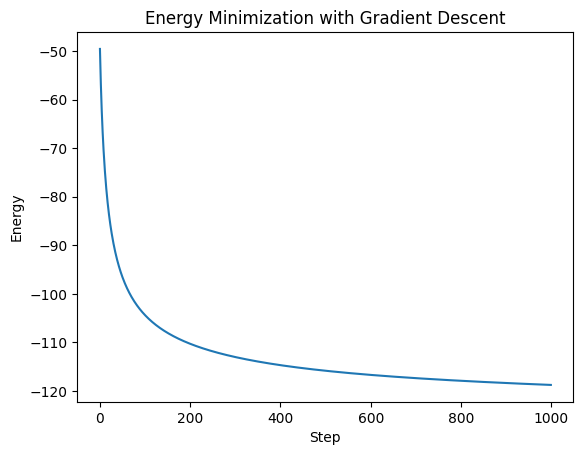

In [85]:

def lj_potential(epsilon, sigma, rij2):
    """Lennard-Jones potential."""
    sr6 = (sigma** 2 / rij2)**3
    return 4.0 * epsilon * (sr6**2 - sr6)

def lj_force(epsilon, sigma, rij2):
    """Lennard-Jones force."""
    sr6 = (sigma** 2 / rij2)**3
    return 48.0 * epsilon * (sr6**2 - 0.5 * sr6) / rij2

def total_energy(gen_particles, L):
    """Total Lennard-Jones energy of the system."""
    u = 0.0
    for p in range(len(gen_particles)):
        for q in range(p+1,len(gen_particles)):
            dx=abs(gen_particles[p][0]-gen_particles[q][0])
            dy=abs(gen_particles[p][1]-gen_particles[q][1])
            dz=abs(gen_particles[p][2]-gen_particles[q][2])
            if dx>L/2:
                dx=L-dx
            if dy>L/2:
                dy=L-dy
            if dz>L/2:
                dz=L-dz
            dist = np.sqrt(dx**2 + dy**2 + dz**2)
            u+= 4*epsilon*((sigma/dist)**12 - (sigma/dist)**6)
    return u

def gradient(gen_particles, L):
    grad = np.zeros_like(gen_particles)
    for i in range(len(gen_particles)):
        for j in range(i + 1, len(gen_particles)):
            rij = gen_particles[i] - gen_particles[j]   # signed vector
            rij -= L * np.round(rij / L)                # minimum image
            rij2 = np.dot(rij, rij)
            force_vector = -lj_force(epsilon, sigma, rij2) * rij
            grad[i] += force_vector
            grad[j] -= force_vector          # Newton's 3rd law
    return grad


def gradient_descent(coords, box_size, learning_rate=0.001, n_steps=1000, tol=1e-6):
    print(f"Initial energy: {total_energy(coords, box_size):.4f}")
    plot=[]
    for step in range(n_steps):
        grad = gradient(coords, box_size)

        # grad = np.clip(grad, -10.0, 10.0)

        coords -= learning_rate * grad
        # coords %= box_size
        e = total_energy(coords, box_size)
        plot.append(e)
        if (step + 1) % 100 == 0:
            print(f"Step {step+1}, Energy: {e:.4f}")

        if np.max(np.abs(grad)) < tol:
            print(f"Converged at step {step+1}")
            break

    print(f"Final energy: {total_energy(coords, box_size):.4f}")
    return coords, plot

optimal_coords, energy_plot = gradient_descent(np.copy(gen_particles), L)
plt.plot(energy_plot)
plt.xlabel('Step')
plt.ylabel('Energy')
plt.title('Energy Minimization with Gradient Descent')
plt.show()

### Result: Energy minimization trend
The energy decreases over optimization steps, indicating the system relaxes toward a lower-energy arrangement. Flattening of the curve suggests convergence toward a local minimum, successfully avoiding large repulsive forces from overlapping cores.

# Generating MD Trajectory

In [86]:
mass = 1.0
epsilon = 0.238
sigma = 3.4
n_steps = 1000
temp=1

def compute_forces(coords, L, epsilon, sigma):
    n = len(coords)
    forces = np.zeros_like(coords)
    U = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            rij = coords[i] - coords[j]
            rij -= L * np.round(rij / L)          # minimum image PBC
            rij2 = np.dot(rij, rij)
            sr6 = (sigma**2 / rij2)**3
            U += 4.0 * epsilon * (sr6**2 - sr6)
            f_mag = 48.0 * epsilon * (sr6**2 - 0.5 * sr6) / rij2
            fvec = f_mag * rij
            forces[i] += fvec
            forces[j] -= fvec
    return forces, U


def init_velocities(n, T, mass=1.0):
    """Maxwell-Boltzmann: narrow width = small K, as per class notes."""
    v = np.random.normal(0.0, np.sqrt(T / mass), size=(n, 3))
    v -= v.mean(axis=0)   # zero net momentum
    return v


def vv_step(coords, vels, forces, L, epsilon, sigma, dt, mass=1.0):
    """Velocity Verlet — board Taylor equation for positions."""
    # x(t+dt) = x(t) + v(t)*dt + 0.5*F(t)/m * dt²
    coords_new = coords + vels * dt + 0.5 * (forces / mass) * dt**2
    coords_new %= L                                   # PBC wrap
    forces_new, U_new = compute_forces(coords_new, L, epsilon, sigma)
    # v(t+dt) = v(t) + 0.5*(F(t)+F(t+dt))/m * dt
    vels_new = vels + 0.5 * ((forces + forces_new) / mass) * dt
    return coords_new, vels_new, forces_new, U_new


def run_md_full(coords_min, L, n_steps, T , dt=0.002):
    coords  = np.copy(coords_min)
    vels    = init_velocities(len(coords), T, mass)
    forces, U = compute_forces(coords, L, epsilon, sigma)

    trajectory  = []
    velocity_traj= []
    K_arr, U_arr, E_arr = [], [], []

    for step in range(n_steps):
        coords, vels, forces, U = vv_step(
            coords, vels, forces, L, epsilon, sigma, dt, mass
        )
        trajectory.append(np.copy(coords))
        velocity_traj.append(np.copy(vels))
        K = 0.5 * mass * np.sum(vels**2)
        K_arr.append(K)
        U_arr.append(U)
        E_arr.append(K + U)

    trajectory  = np.array(trajectory)                          # (n_steps, N, 3)
    velocity_traj = np.array(velocity_traj)                     # (n_steps, N, 3)

    return trajectory, velocity_traj, K_arr, U_arr, E_arr


trajectory, velocity_traj, K_arr, U_arr, E_arr = run_md_full(optimal_coords, L, n_steps, temp)


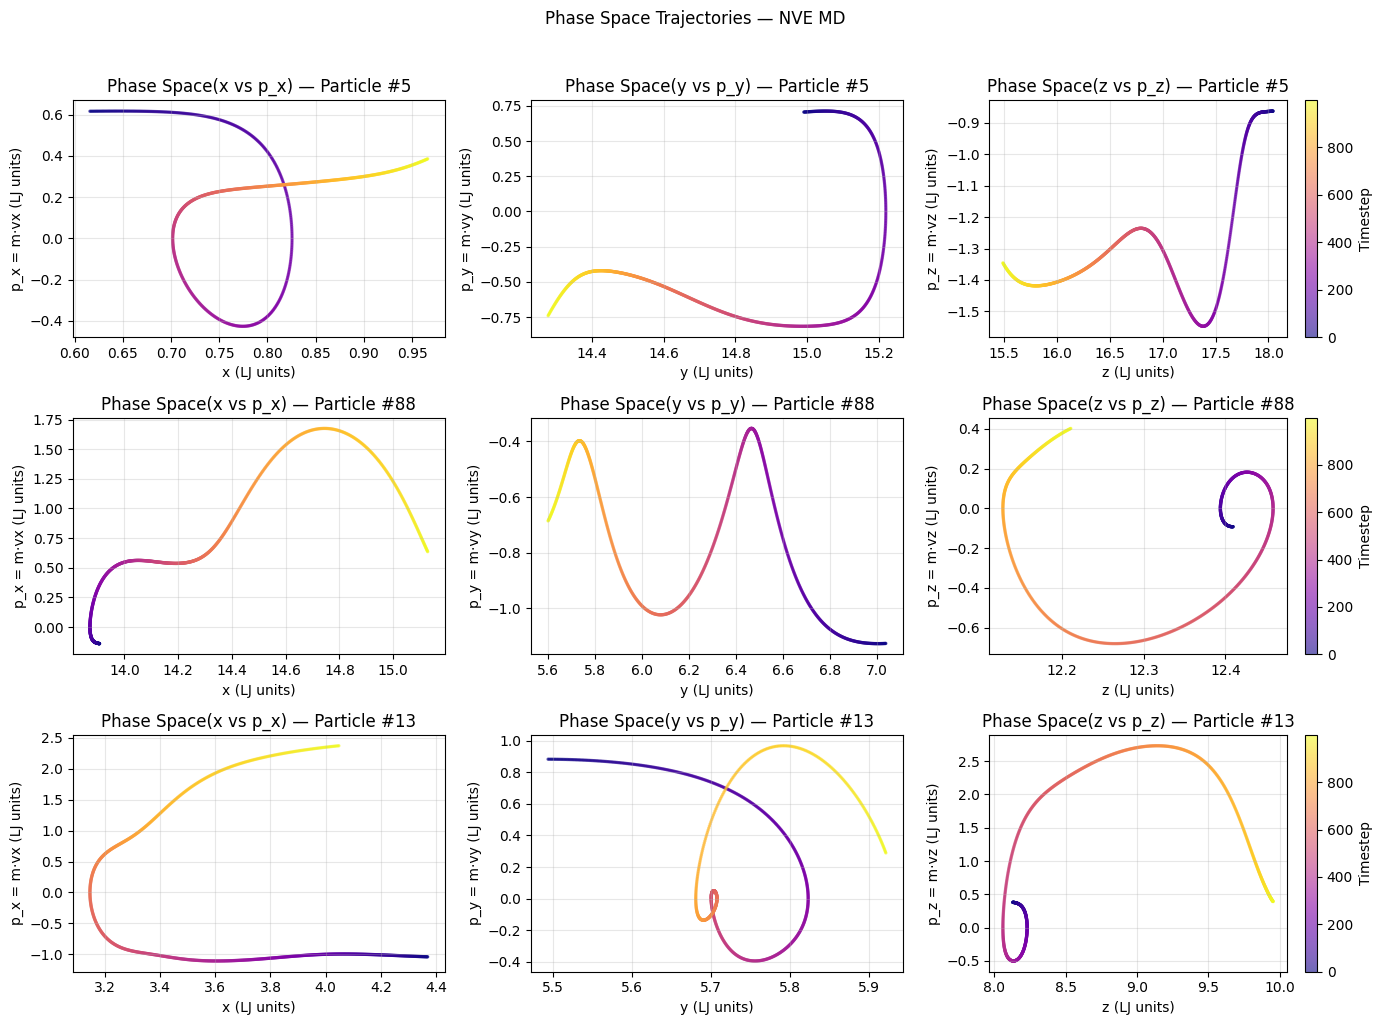

In [87]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
comp_labels = ["x", "y", "z"]
clrs = ["#636EFA", "#EF553B", "#00CC96"]

rand_partics = np.random.choice(len(optimal_coords), size=3, replace=False)
steps = np.arange(n_steps)

for pid, partic in enumerate(rand_partics):
    x = trajectory[:, partic, 0]
    p = mass * velocity_traj[:, partic, 0]

    sc = axes[pid][0].scatter(x, p, c=steps, cmap="plasma", s=2, alpha=0.6)
    axes[pid][0].set_xlabel("x (LJ units)")
    axes[pid][0].set_ylabel("p_x = m·vx (LJ units)")
    axes[pid][0].set_title(f"Phase Space(x vs p_x) — Particle #{partic}")
    axes[pid][0].grid(alpha=0.3)

for pid, partic in enumerate(rand_partics):
    x = trajectory[:, partic, 1]
    p = mass * velocity_traj[:, partic, 1]

    sc = axes[pid][1].scatter(x, p, c=steps, cmap="plasma", s=2, alpha=0.6)
    axes[pid][1].set_xlabel("y (LJ units)")
    axes[pid][1].set_ylabel("p_y = m·vy (LJ units)")
    axes[pid][1].set_title(f"Phase Space(y vs p_y) — Particle #{partic}")
    axes[pid][1].grid(alpha=0.3)

for pid, partic in enumerate(rand_partics):
    x = trajectory[:, partic, 2]
    p = mass * velocity_traj[:, partic, 2]

    sc = axes[pid][2].scatter(x, p, c=steps, cmap="plasma", s=2, alpha=0.6)
    axes[pid][2].set_xlabel("z (LJ units)")
    axes[pid][2].set_ylabel("p_z = m·vz (LJ units)")
    axes[pid][2].set_title(f"Phase Space(z vs p_z) — Particle #{partic}")
    axes[pid][2].grid(alpha=0.3)
    plt.colorbar(sc, ax=axes[pid][2], label="Timestep")

plt.suptitle("Phase Space Trajectories — NVE MD", y=1.02)
plt.tight_layout()
plt.show()

### Result: Phase-Space Trajectories

These subplots visualize the phase-space evolution—\((q_i, p_i)\) for \(x\), \(y\), and \(z\) components—of three randomly selected particles throughout the simulation.

* **Bounded Dynamics:** The trajectories remain fully bounded, demonstrating that the particles are stably confined by periodic boundary conditions and the repulsive cores of their neighbors (the "caging" effect).
* **Time Evolution:** The color mapping represents the progression of time. The non-overlapping, erratic orbits trace the continuous exchange of kinetic and potential energy, characteristic of a chaotic many-body system governed by Lennard-Jones interactions. 
* **Integration Stability:** The absence of diverging momenta or positions confirms that the Velocity Verlet integration successfully maintains numerical and physical stability within the NVE ensemble.

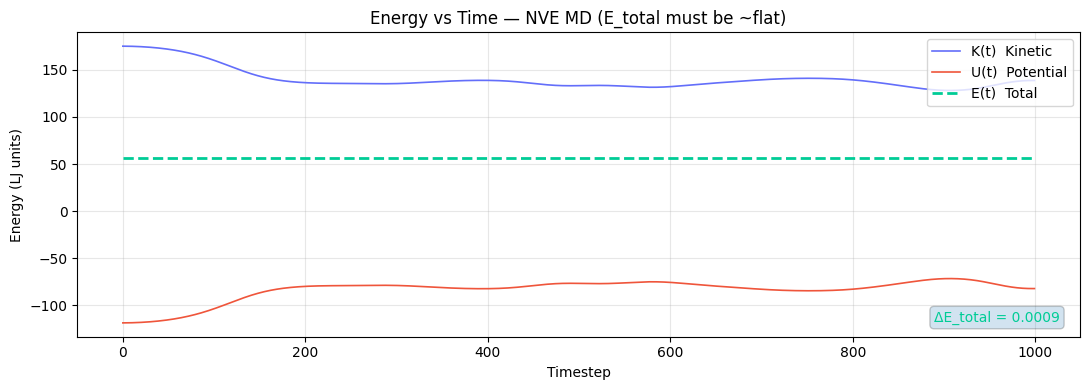

In [88]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(steps, K_arr, label="K(t)  Kinetic",   lw=1.2, color="#636EFA")
ax.plot(steps, U_arr, label="U(t)  Potential", lw=1.2, color="#EF553B")
ax.plot(steps, E_arr, label="E(t)  Total",     lw=2.0, color="#00CC96",
        linestyle="--")

# Annotate energy drift
e_drift = abs(max(E_arr) - min(E_arr))
ax.text(0.98, 0.05, f"ΔE_total = {e_drift:.4f}",
        transform=ax.transAxes, ha="right", fontsize=10,
        color="#00CC96", bbox=dict(boxstyle="round", alpha=0.2))

ax.set_xlabel("Timestep")
ax.set_ylabel("Energy (LJ units)")
ax.set_title("Energy vs Time — NVE MD (E_total must be ~flat)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Result: Energy conservation in NVE
Kinetic and potential energies exchange over time, while total energy stays approximately constant. The small deltaE_total drift value indicates good numerical stability of the integration.

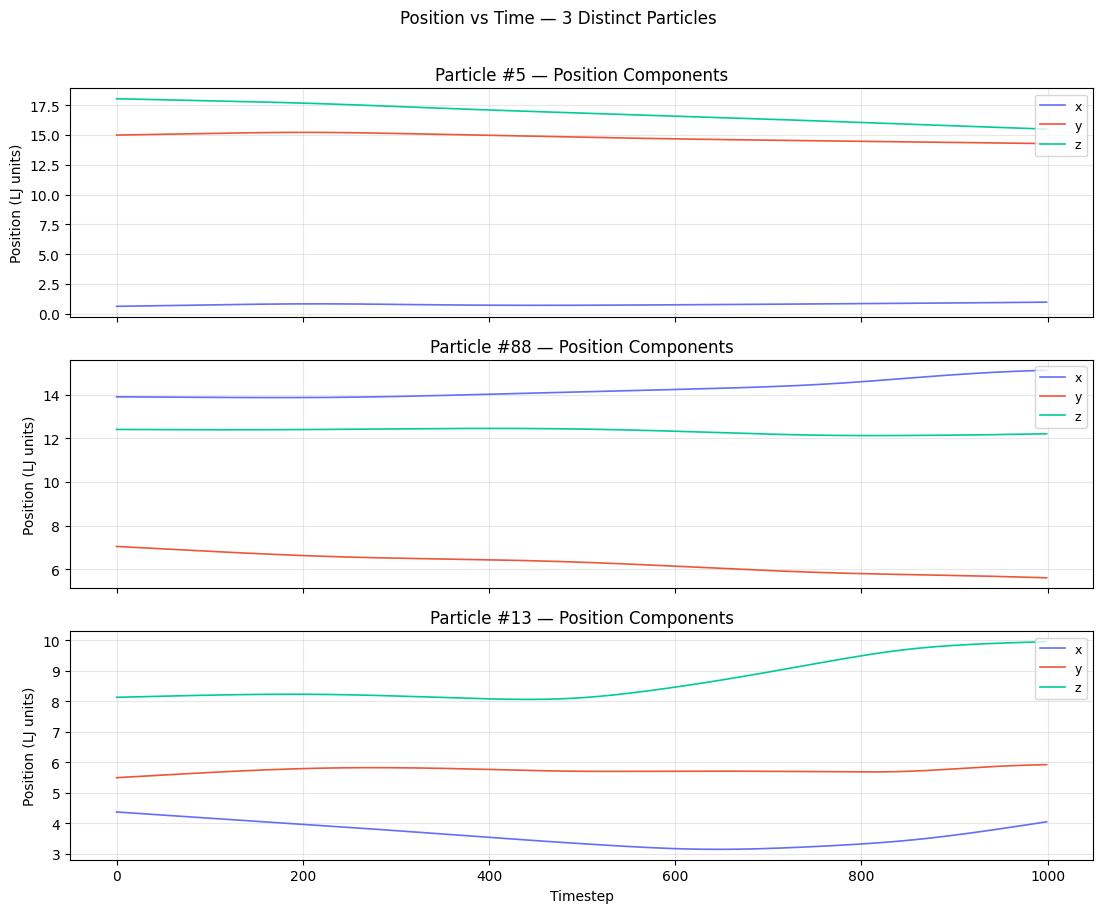

In [89]:
comp  = ["x", "y", "z"]
clrs  = ["#636EFA", "#EF553B", "#00CC96"]

# ── 7a: Position vs time ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

for pid, partic in enumerate(rand_partics):
    for ci in range(3):
        axes[pid].plot(steps, trajectory[:, partic, ci],
                       color=clrs[ci], lw=1.2, label=comp[ci])
    axes[pid].set_ylabel("Position (LJ units)")
    axes[pid].set_title(f"Particle #{partic} — Position Components")
    axes[pid].legend(loc="upper right", fontsize=9)
    axes[pid].grid(alpha=0.3)

axes[-1].set_xlabel("Timestep")
plt.suptitle("Position vs Time — 3 Distinct Particles", y=1.01)
plt.tight_layout()
plt.show()

### Result: Position components vs time
The plot illustrates the temporal evolution of the $x$, $y$, and $z$ spatial coordinates for selected particles. The observed trajectories reflect complex many-body interactions governed by the Lennard-Jones potential. Instead of simple harmonic motion, the particles exhibit characteristic thermal diffusion and localized caging effects caused by collisions with neighboring particles, while being correctly constrained by the simulation box's periodic boundary conditions.

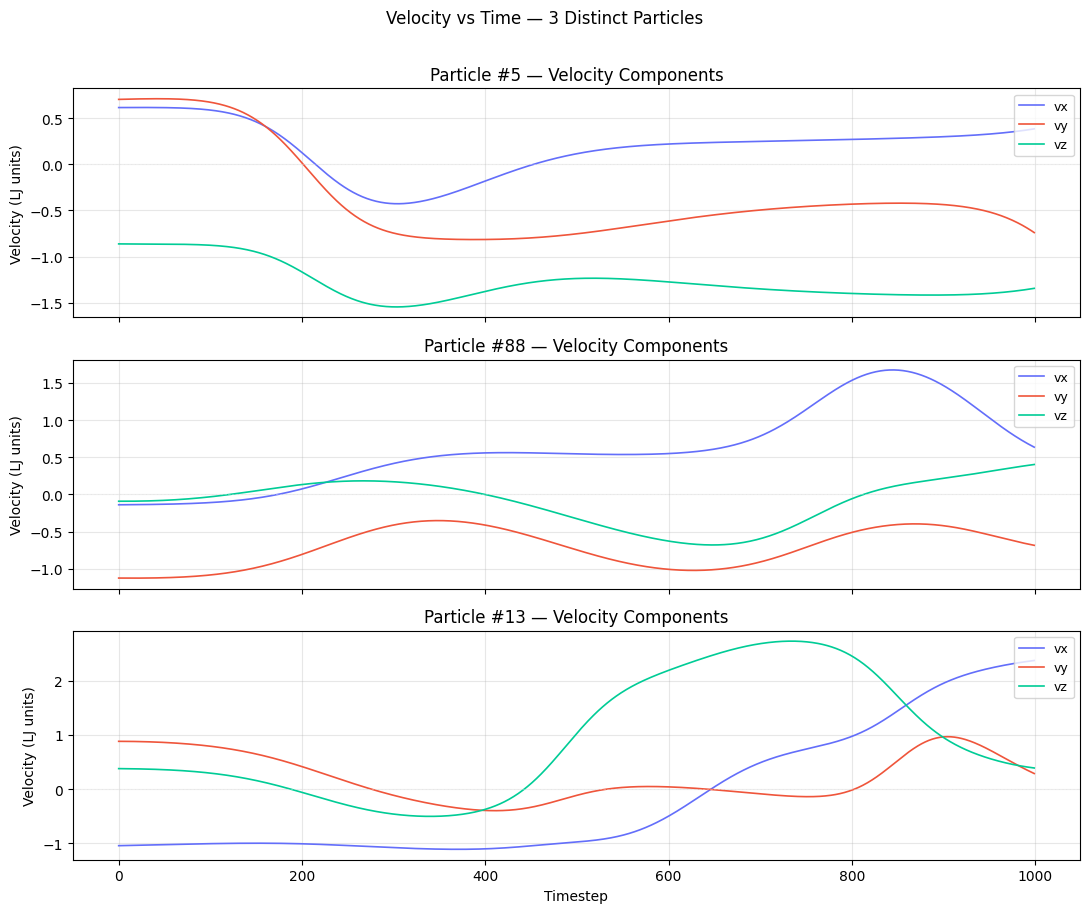

In [90]:
# ── 7b: Velocity vs time ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

for pid, partic in enumerate(rand_partics):
    for ci in range(3):
        axes[pid].plot(steps, velocity_traj[:, partic, ci],
                       color=clrs[ci], lw=1.2, label=f"v{comp[ci]}")
    axes[pid].set_ylabel("Velocity (LJ units)")
    axes[pid].set_title(f"Particle #{partic} — Velocity Components")
    axes[pid].legend(loc="upper right", fontsize=9)
    axes[pid].axhline(0, color="white", lw=0.5, linestyle="--", alpha=0.4)
    axes[pid].grid(alpha=0.3)

axes[-1].set_xlabel("Timestep")
plt.suptitle("Velocity vs Time — 3 Distinct Particles", y=1.01)
plt.tight_layout()
plt.show()

### Result: Velocity components vs time
Velocity components continuously fluctuate around zero, maintaining the zero net momentum of the system. The time variation captures the ongoing energy exchange among particles, which occurs through Lennard-Jones interactions. As particles move, they experience attractive and repulsive forces from their neighbors, causing their velocities (and thus kinetic energy) to increase or decrease. This continuous transfer between potential and kinetic energy among the interacting particles drives the thermalization of the system.

# Distribution of momentum of particles

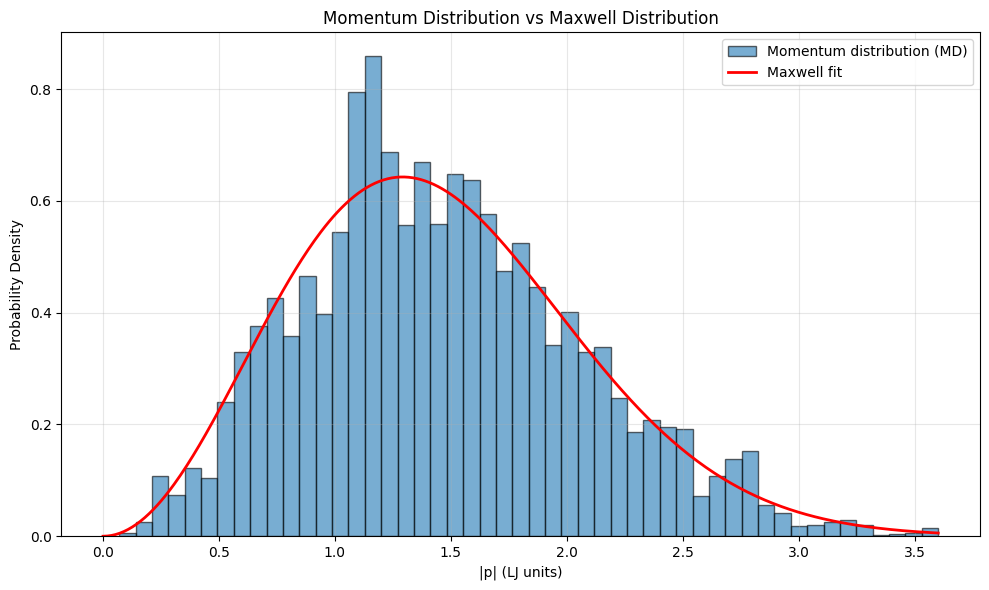

In [91]:
burn_in = len(velocity_traj) // 2  # use the second half of the trajectory for equilibrium
vel_arr = np.asarray(velocity_traj, dtype=float)
vel_eq = vel_arr[burn_in:]

momenta = mass * vel_eq
p_mag = np.linalg.norm(momenta, axis=2).ravel()
p_components = momenta.reshape(-1, 3)

a = p_components.std()
p_grid = np.linspace(0.0, p_mag.max(), 400)
maxwell_pdf = np.sqrt(2 / np.pi) * (p_grid**2 / a**3) * np.exp(-(p_grid**2) / (2 * a**2))

plt.figure(figsize=(10, 6))
plt.hist(p_mag, bins=50, density=True, alpha=0.6, edgecolor='black', label='Momentum distribution (MD)')
plt.plot(p_grid, maxwell_pdf, 'r-', linewidth=2, label='Maxwell fit')
plt.xlabel('|p| (LJ units)')
plt.ylabel('Probability Density')
plt.title('Momentum Distribution vs Maxwell Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Result: Momentum Distribution and Maxwell-Boltzmann Fit

The histogram illustrates the distribution of particle momentum magnitudes derived from the equilibrium phase of the trajectory, overlaid with the theoretical Maxwell-Boltzmann probability density function. 

**Key Takeaways:**
* **Thermalization:** The strong alignment between the underlying molecular dynamics data and the analytical curve confirms that the system has properly relaxed into thermal equilibrium.
* **Statistical Mechanics Validation:** Even within a deterministic NVE (microcanonical) ensemble, the particle statistics conform to the expected macroscopic thermodynamic behavior, supporting the ergodic hypothesis. 
* **Integrator Reliability:** This agreement acts as a robust internal check, validating the physical accuracy of the Velocity Verlet integration and the Lennard-Jones force calculations over the simulation period.